# BdG 入门交互教程
**Bogoliubov–de Gennes：从均匀能谱到局域态密度**

先完成第一课 BCS。本课输入固定 Δ，不求自洽，也不计算 Tc。
采用自旋单态约化基底 $(c_\uparrow,c_\downarrow^\dagger)$，不是无自旋 Kitaev 链。
所有能量以跃迁能 J 为单位；默认 J=1，μ=-0.5，Δ=0.25。
建议每格运行后先预测下一张图，再修改一个参数。

## 1. 环境与最小 2×2 问题
使用 Hermitian eigensolver（厄米本征求解器）而不是一般矩阵求解器。

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from bdg import (momentum_block, bdg_chain, analytic_chain_spectrum,
                 particle_hole_operator, electron_ldos)
print("Python", sys.version.split()[0], "NumPy", np.__version__)
xi, delta = 0.6, 0.25
H = momentum_block(xi, delta)
values, vectors = np.linalg.eigh(H)
expected = np.sqrt(xi**2 + abs(delta)**2)
print(H)
print("numeric:", values, "analytic:", [-expected, expected])
assert np.allclose(values, [-expected, expected])

Python 3.12.4 NumPy 1.26.4
[[ 0.6 +0.j -0.25-0.j]
 [-0.25+0.j -0.6 +0.j]]
numeric: [-0.65  0.65] analytic: [-0.65, 0.65]


## 2. 能谱与相干因子（coherence factors）
正能态电子权重 $|u|^2=(1+ξ/E)/2$；能谱正负对称不等于电子 LDOS 正负对称。

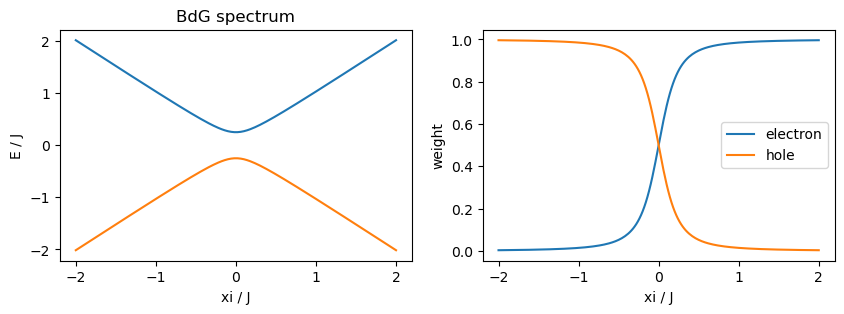

In [2]:
xis = np.linspace(-2, 2, 201)
energies = np.sqrt(xis**2 + delta**2)
u2 = np.array([abs(np.linalg.eigh(momentum_block(x, delta))[1][0, 1])**2
               for x in xis])
assert np.allclose(u2, (1 + xis/energies)/2)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(xis, energies); axes[0].plot(xis, -energies)
axes[0].set(xlabel="xi / J", ylabel="E / J", title="BdG spectrum")
axes[1].plot(xis, u2, label="electron")
axes[1].plot(xis, 1-u2, label="hole")
axes[1].set(xlabel="xi / J", ylabel="weight")
axes[1].legend(); plt.show()

## 3. 周期与开放边界（periodic/open boundary conditions）
实空间矩阵维数 2N。逐个比较排序后的本征值，不凭图形判断算法正确。

In [3]:
n, mu = 48, -0.5
errors = {}
for boundary in ["periodic", "open"]:
    matrix = bdg_chain(n, mu=mu, delta=delta, boundary=boundary)
    values = np.linalg.eigvalsh(matrix)
    reference = analytic_chain_spectrum(n, mu=mu, delta=delta, boundary=boundary)
    errors[boundary] = np.max(abs(values-reference))
    assert errors[boundary] < 1e-12
print("maximum analytic errors:", errors)

maximum analytic errors: {'periodic': 2.4424906541753444e-15, 'open': 5.329070518200751e-15}


## 4. 厄米性、粒子–空穴结构与完备性
本课约化块使用 $C=τ_yK$，满足 $CHC^{-1}=-H$、$C^2=-1$。
这不是任意 Nambu 基底的统一公式。基底变换后矩阵和对称算符必须一起变换。

In [4]:
matrix = bdg_chain(n, mu=mu, delta=delta)
values, vectors = np.linalg.eigh(matrix)
C = particle_hole_operator(n)
print("Hermiticity:", np.max(abs(matrix-matrix.conj().T)))
print("reduced-block PH:", np.max(abs(C@matrix.conj()@C.conj().T + matrix)))
print("eigenpair residual:", np.max(abs(matrix@vectors-vectors*values)))
weights = np.sum(abs(vectors[:n, :])**2, axis=1)
print("single-spin electron completeness:", weights.min(), weights.max())
assert np.allclose(weights, 1)

Hermiticity: 0.0


reduced-block PH: 0.0
eigenpair residual: 1.2698175844150228e-15
single-spin electron completeness: 0.9999999999999996 1.0000000000000018


## 5. 局域态密度（local density of states, LDOS）
对全部 2N 个态的电子分量求和一次：
$ρ_↑(i,E)=\sum_ν|u_{iν}|^2L_η(E-E_ν)$。
不要再额外加入负能伙伴。η 是绘图谱展宽，不是 QE 的 degauss。

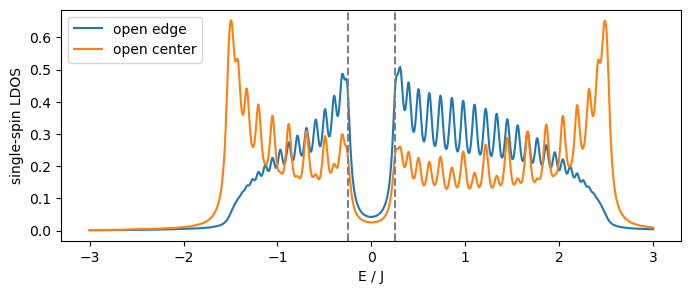

center weight on finite window: 0.9869219999762344
minimum positive eigenvalue: 0.2559695221750683


In [5]:
grid = np.linspace(-3, 3, 1201)
rho = electron_ldos(grid, values, vectors, eta=0.04)
plt.figure(figsize=(8, 3))
plt.plot(grid, rho[:, 0], label="open edge")
plt.plot(grid, rho[:, n//2], label="open center")
plt.axvline(delta, color="gray", ls="--")
plt.axvline(-delta, color="gray", ls="--")
plt.xlabel("E / J"); plt.ylabel("single-spin LDOS")
plt.legend(); plt.show()
print("center weight on finite window:", np.trapz(rho[:, n//2], grid))
print("minimum positive eigenvalue:", values[values>0].min())

## 6. 有限窗与展宽
无限能量窗的权重为 1；有限窗漏掉 Lorentzian 尾部。无需人为重归一化。

window 3 integrated weight 0.986922063490995
window 6 integrated weight 0.9954477864322533
window 12 integrated weight 0.9978428737622345


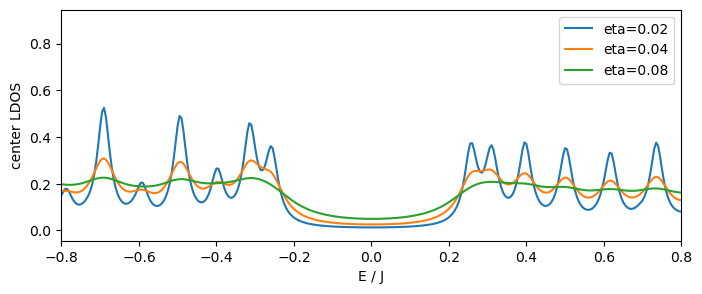

In [6]:
for window in [3, 6, 12]:
    energy_grid = np.linspace(-window, window, 8001)
    center_rho = electron_ldos(energy_grid, values, vectors, eta=0.04)[:, n//2]
    print("window", window, "integrated weight", np.trapz(center_rho, energy_grid))
fig, ax = plt.subplots(figsize=(8, 3))
for eta in [0.02, 0.04, 0.08]:
    curve = electron_ldos(grid, values, vectors, eta=eta)
    ax.plot(grid, curve[:, n//2], label=f"eta={eta}")
ax.set(xlim=(-0.8, 0.8), xlabel="E / J", ylabel="center LDOS")
ax.legend(); plt.show()

## 7. 标量杂质不等于磁性杂质
仅在中心增加自旋无关势 U=2，仍固定均匀 Δ。
此时实 h 可对角化，每个正常态能级 ε 都对应 $±\sqrt{ε^2+|Δ|^2}$。
所以不应产生 gap 内的 Shiba 或 Majorana 态。

impurity minimum positive eigenvalue: 0.2540643593854445


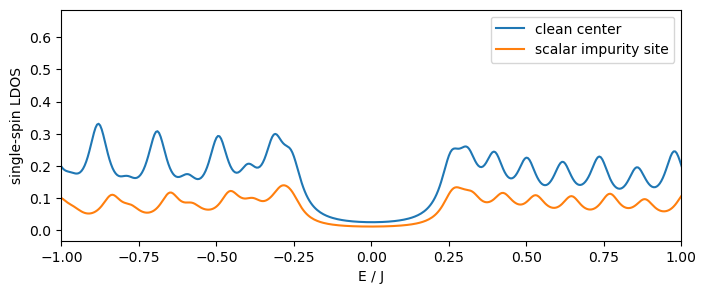

In [7]:
potential = np.zeros(n); potential[n//2] = 2.0
impurity_values, impurity_vectors = np.linalg.eigh(
    bdg_chain(n, mu=mu, delta=delta, potential=potential))
print("impurity minimum positive eigenvalue:", impurity_values[impurity_values>0].min())
assert np.min(abs(impurity_values)) >= abs(delta)-1e-12
impurity_rho = electron_ldos(grid, impurity_values, impurity_vectors)
plt.figure(figsize=(8, 3))
plt.plot(grid, rho[:, n//2], label="clean center")
plt.plot(grid, impurity_rho[:, n//2], label="scalar impurity site")
plt.xlim(-1, 1); plt.xlabel("E / J"); plt.ylabel("single-spin LDOS")
plt.legend(); plt.show()

## 8. 尺寸与整体相位
有限尺寸的最低正能可能高于 Δ；整体配对相位不改变谱。

In [8]:
for sites in [24, 48, 96]:
    spectrum = np.linalg.eigvalsh(bdg_chain(sites, mu=mu, delta=delta))
    print("N", sites, "minimum positive E", spectrum[spectrum>0].min())
phase_spectrum = np.linalg.eigvalsh(bdg_chain(n, mu=mu, delta=delta*np.exp(0.7j)))
assert np.allclose(phase_spectrum, values)
print("Global-phase check passed; spatial phase variation is a different problem.")

N 24 minimum positive E 0.2764634198229674
N 48 minimum positive E 0.255969522175069
N 96 minimum positive E 0.250717182912232


Global-phase check passed; spatial phase variation is a different problem.


## 独立练习
1. 将 Δ 设为 0，验证 ±ξ 的正常态极限。零本征值要用容差判定。
2. 将 μ 设为 0，比较电子 LDOS 的能量对称性；解释与 μ=-0.5 的差异。
3. 固定 η 比较 N，再固定 N 比较 η，不要一次改变两个变量。
4. 用 eigenvector residual 而非曲线美观程度判断正确性。
5. 解释：为何本 Notebook 不能给出 Al 的 Tc？

答案与符号推导见同目录《BdG理论与计算入门教程.md》。
延伸：[Kwant 官方 superconductors 教程](https://kwant-project.org/doc/1/tutorial/superconductors)。
本课原创教学代码，不是该教程输运曲线或某篇原始论文的定量复现。